In [15]:
import pandas as pd
from mlxtend.frequent_patterns import apriori,association_rules
from mlxtend.preprocessing import TransactionEncoder
import matplotlib.pyplot as plt

In [16]:
df=pd.read_csv('Market_Basket_Optimisation.csv', header=None)

In [17]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
trans=[]
for i in range(0,df.shape[0]):
    a=[str(item) for item in df.iloc[i] if str(item) !='nan']
    trans.append(a)
trans[:5]   

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['turkey', 'avocado'],
 ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea']]

In [28]:
te = TransactionEncoder()

te_ary = te.fit(trans).transform(trans)
df = pd.DataFrame(te_ary, columns=te.columns_)

feqi = apriori(df,min_support=0.03 , use_colnames=True)

rules = association_rules(feqi,metric="confidence",min_threshold=0.3)


print(feqi)

rules


     support                            itemsets
0   0.033329                           (avocado)
1   0.033729                          (brownies)
2   0.087188                           (burgers)
3   0.030129                            (butter)
4   0.081056                              (cake)
5   0.046794                         (champagne)
6   0.059992                           (chicken)
7   0.163845                         (chocolate)
8   0.080389                           (cookies)
9   0.051060                       (cooking oil)
10  0.031862                    (cottage cheese)
11  0.179709                              (eggs)
12  0.079323                          (escalope)
13  0.170911                      (french fries)
14  0.043061                       (fresh bread)
15  0.063325                   (frozen smoothie)
16  0.095321                 (frozen vegetables)
17  0.052393                     (grated cheese)
18  0.132116                         (green tea)
19  0.098254        

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,(chocolate),(mineral water),0.163845,0.238368,0.052660,0.321400,1.348332,0.013604,1.122357,0.308965
1,(frozen vegetables),(mineral water),0.095321,0.238368,0.035729,0.374825,1.572463,0.013007,1.218270,0.402413
2,(ground beef),(mineral water),0.098254,0.238368,0.040928,0.416554,1.747522,0.017507,1.305401,0.474369
3,(ground beef),(spaghetti),0.098254,0.174110,0.039195,0.398915,2.291162,0.022088,1.373997,0.624943
4,(milk),(mineral water),0.129583,0.238368,0.047994,0.370370,1.553774,0.017105,1.209650,0.409465
5,(pancakes),(mineral water),0.095054,0.238368,0.033729,0.354839,1.488616,0.011071,1.180529,0.362712
6,(spaghetti),(mineral water),0.174110,0.238368,0.059725,0.343032,1.439085,0.018223,1.159314,0.369437


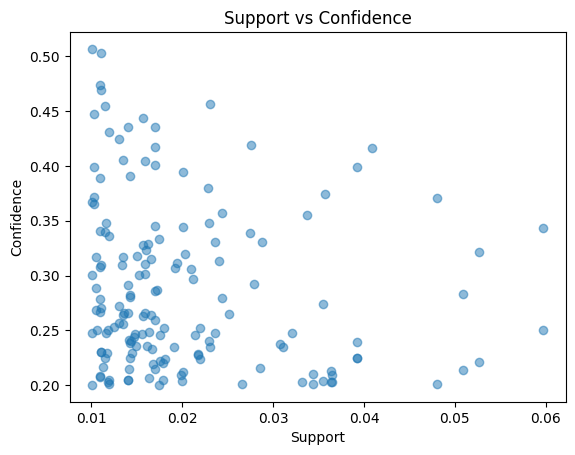

In [8]:
plt.scatter(rules['support'],rules['confidence'],alpha=0.5)
plt.title('Support vs Confidence')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()

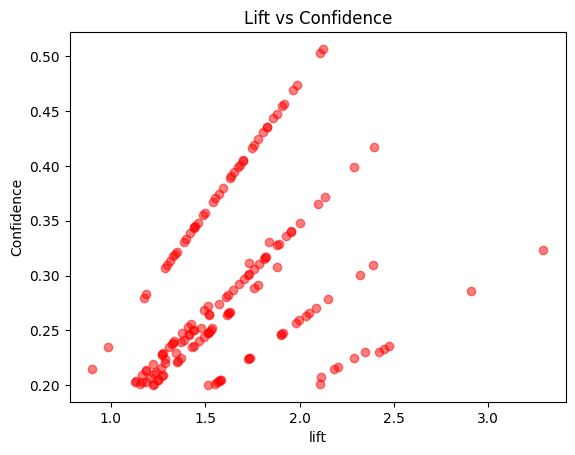

In [9]:
plt.scatter(rules['lift'],rules['confidence'] ,alpha = 0.5 , color='red')
plt.title('Lift vs Confidence')
plt.xlabel('lift')
plt.ylabel('Confidence')
plt.show()

In [10]:
rules_h_c = association_rules(feqi,metric="confidence",min_threshold=0.5)

rules_h_c.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction,zhangs_metric
0,"(ground beef, eggs)",(mineral water),0.019997,0.238368,0.010132,0.506667,2.125563,0.005365,1.543848,0.540342
1,"(ground beef, milk)",(mineral water),0.021997,0.238368,0.011065,0.503030,2.110308,0.005822,1.532552,0.537969


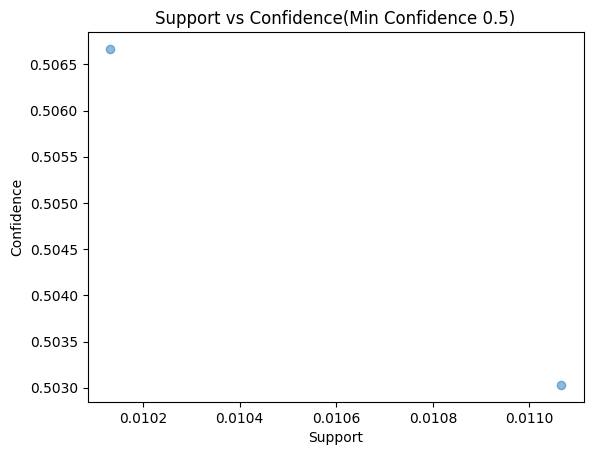

In [11]:
plt.scatter(rules_h_c['support'],rules_h_c['confidence'],alpha=0.5)
plt.title('Support vs Confidence(Min Confidence 0.5)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.show()

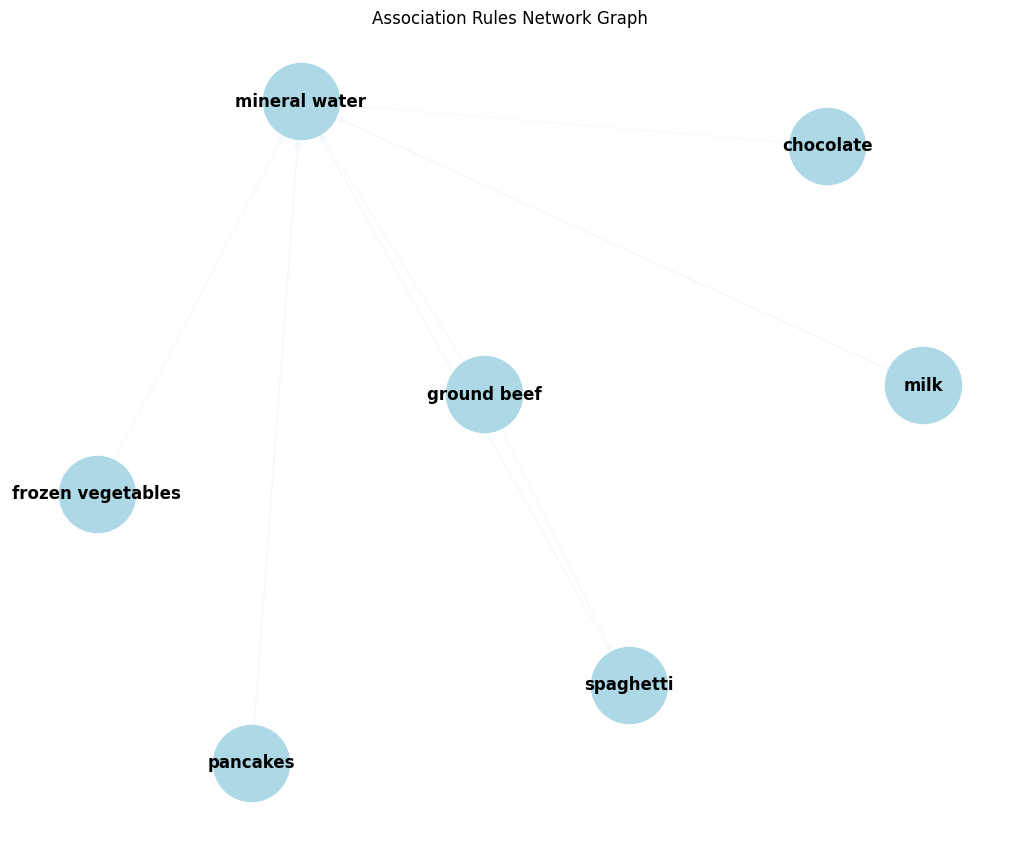

In [26]:
import networkx as nx

# Create a network graph to visualize association rules
G = nx.DiGraph()

for i, rule in rules.iterrows():
    G.add_edge(tuple(rule['antecedents'])[0], tuple(rule['consequents'])[0], weight=rule['lift'])

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, k=2)  # Define the layout
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='lightblue', font_size=12, font_weight='bold', edge_color=plt.cm.Blues(range(len(G.edges))))
plt.title('Association Rules Network Graph')
plt.show()


In [32]:
max_len = feqi['itemsets'].apply(lambda x: len(x)).max()
last_freq_itemsets = feqi[feqi['itemsets'].apply(lambda x: len(x)) == max_len]
print(last_freq_itemsets)

     support                            itemsets
36  0.033196                   (eggs, chocolate)
37  0.034395           (chocolate, french fries)
38  0.032129                   (milk, chocolate)
39  0.052660          (chocolate, mineral water)
40  0.039195              (spaghetti, chocolate)
41  0.036395                (eggs, french fries)
42  0.030796                        (milk, eggs)
43  0.050927               (eggs, mineral water)
44  0.036528                   (spaghetti, eggs)
45  0.033729       (french fries, mineral water)
46  0.035729  (frozen vegetables, mineral water)
47  0.031063          (green tea, mineral water)
48  0.040928        (ground beef, mineral water)
49  0.039195            (spaghetti, ground beef)
50  0.047994               (milk, mineral water)
51  0.035462                   (spaghetti, milk)
52  0.033729           (pancakes, mineral water)
53  0.059725          (spaghetti, mineral water)
